# Análisis Exploratorio de Datos — Maestro de Materiales M402
## Tipo ZSUM · Corporación Multi Inversiones · Mayo 2026
---
**Proyecto:** Asistente Inteligente de Gestión de Materiales SAP  
**Equipo:** Alejandra Alvarado · Rudy Osorio · Erick Marroquin  
**Programa:** MBIA · Universidad del Valle de Guatemala  
**Fecha corte datos:** 29 de mayo 2026

### Objetivo del EDA
Caracterizar el catálogo de suministros (ZSUM) del mandante 402 para:
1. Cuantificar el problema de duplicidad real
2. Identificar patrones de descripción y nomenclatura
3. Detectar materiales mal categorizados
4. Fundamentar la selección de modelos de IA para el proyecto final


In [1]:
# ── Resolucion de rutas (agregado al importar al repositorio GAMMA) ──────
# Localiza data/xlsx tanto dentro del contenedor Jupyter como en ejecucion local,
# sin importar la profundidad del notebook respecto de lab/.
import os

def _find_data_dir():
    if os.path.isdir('/home/jovyan/work/data/xlsx'):
        return '/home/jovyan/work/data/xlsx'
    d = os.path.abspath('.')
    for _ in range(6):
        cand = os.path.join(d, 'data', 'xlsx')
        if os.path.isdir(cand):
            return cand
        d = os.path.dirname(d)
    raise FileNotFoundError('No se encontro el directorio data/xlsx')

DATA_DIR = _find_data_dir()
FIG_DIR  = os.path.join(os.path.abspath('.'), 'figuras')
os.makedirs(FIG_DIR, exist_ok=True)
print('DATA_DIR:', DATA_DIR)
print('FIG_DIR :', FIG_DIR)


DATA_DIR: /Users/menene/code/www/mbia_gamma/lab/data/xlsx
FIG_DIR : /Users/menene/code/www/mbia_gamma/lab/notebooks/eda/figuras


## 1. Carga y Perfil Inicial del Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Paleta corporativa CMI
CMI_VERDE  = '#1A6635'
CMI_CLARO  = '#D6EFE0'
CMI_ORO    = '#C9A84C'
CMI_GRIS   = '#4A4A4A'
CMI_ROJO   = '#C0392B'

# ── Carga de archivos ────────────────────────────────────────────────────────
df = pd.read_excel(os.path.join(DATA_DIR, "ZSUM_29MAY26.xlsx"))
df_cls = pd.read_excel(os.path.join(DATA_DIR, "Clases de material DEN.xlsx"))

# Renombrar columna duplicada
df = df.rename(columns={"Texto breve de material.1": "Texto_breve_2"})

print(f"Registros ZSUM:        {len(df):,}")
print(f"Columnas:              {df.columns.tolist()}")
print(f"Clases en catálogo:    {len(df_cls):,}")
print(f"Tipos de mat en clases: {df_cls['Tipo de Material'].nunique()}")
df.head(3)


Registros ZSUM:        13,399
Columnas:              ['Material', 'PB nivel mandante', 'Tipo material', 'Grupo de artículos', 'Nºmaterial antiguo', 'Unidad medida base', 'Info fabr./insp.', 'Denom.estándar', 'Texto breve de material', 'Texto_breve_2']
Clases en catálogo:    1,539
Tipos de mat en clases: 19


,Material,PB nivel mandante,Tipo material,Grupo de artículos,Nºmaterial antiguo,Unidad medida base,Info fabr./insp.,Denom.estándar,Texto breve de material,Texto_breve_2
0,11001287,NaN,ZSUM,SEG221000,14000080,UN,46161602,009882,BOTE:GAS PRUEBA DETECTOR HUMOS HONEYWELL,BOTE:GAS PRUEBA DETECTOR HUMOS HONEYWELL
1,11001289,NaN,ZSUM,SEG221000,14000232,UN,46161602,009882,BOTE.P/RECOGIDA DE MUESTRAS DE ACEITE,BOTE.P/RECOGIDA DE MUESTRAS DE ACEITE
2,11001290,NaN,ZSUM,SEG221000,14000234,UN,46161602,009882,BOTE:P/MUESTRA DE GRASA,BOTE:P/MUESTRA DE GRASA


## 2. Completitud de Campos Críticos
> **Hallazgo clave:** 3.7% sin UNSPSC, 7.8% sin clase asignada, 34.5% sin número de material antiguo.  
> Estos vacíos son exactamente el tipo de error que el asistente inteligente prevendrá.


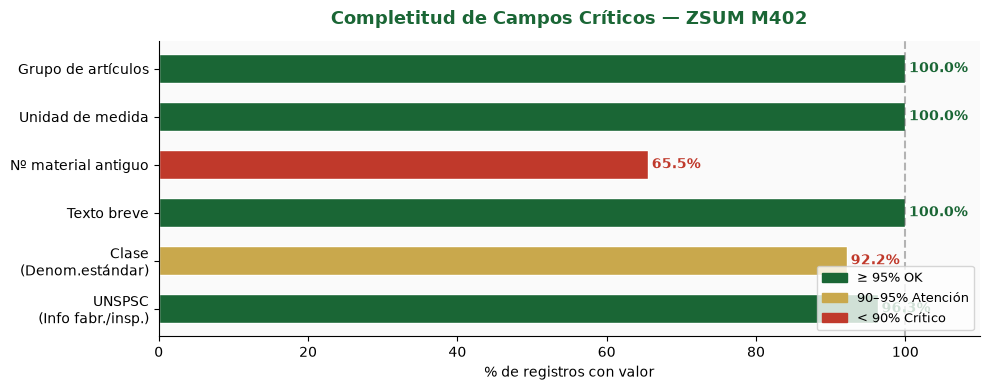

Total registros: 13,399
Sin UNSPSC:  493 (3.7%)
Sin Clase:   1,046 (7.8%)
Sin Nº ant:  4,617 (34.5%)
Bloqueados (PB=X): 2,539 (18.9%)


In [3]:
# Campos críticos y su completitud
campos = {
    'UNSPSC\n(Info fabr./insp.)': df['Info fabr./insp.'].notna().mean() * 100,
    'Clase\n(Denom.estándar)':    df['Denom.estándar'].notna().mean() * 100,
    'Texto breve':                 df['Texto breve de material'].notna().mean() * 100,
    'Nº material antiguo':         df['Nºmaterial antiguo'].notna().mean() * 100,
    'Unidad de medida':            df['Unidad medida base'].notna().mean() * 100,
    'Grupo de artículos':          df['Grupo de artículos'].notna().mean() * 100,
}

fig, ax = plt.subplots(figsize=(10, 4))
colores = [CMI_VERDE if v >= 95 else CMI_ORO if v >= 90 else CMI_ROJO for v in campos.values()]
bars = ax.barh(list(campos.keys()), list(campos.values()), color=colores, edgecolor='white', height=0.6)
ax.set_xlim(0, 110)
ax.axvline(100, color=CMI_GRIS, linestyle='--', alpha=0.4)
for bar, val in zip(bars, campos.values()):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold',
            color=CMI_VERDE if val >= 95 else CMI_ROJO)
legend = [mpatches.Patch(color=CMI_VERDE, label='≥ 95% OK'),
          mpatches.Patch(color=CMI_ORO, label='90–95% Atención'),
          mpatches.Patch(color=CMI_ROJO, label='< 90% Crítico')]
ax.legend(handles=legend, loc='lower right', fontsize=9)
ax.set_title('Completitud de Campos Críticos — ZSUM M402', fontsize=13,
             fontweight='bold', color=CMI_VERDE, pad=12)
ax.set_xlabel('% de registros con valor', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_completitud.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Total registros: {len(df):,}")
print(f"Sin UNSPSC:  {df['Info fabr./insp.'].isna().sum():,} ({df['Info fabr./insp.'].isna().mean()*100:.1f}%)")
print(f"Sin Clase:   {df['Denom.estándar'].isna().sum():,} ({df['Denom.estándar'].isna().mean()*100:.1f}%)")
print(f"Sin Nº ant:  {df['Nºmaterial antiguo'].isna().sum():,} ({df['Nºmaterial antiguo'].isna().mean()*100:.1f}%)")
print(f"Bloqueados (PB=X): {df['PB nivel mandante'].notna().sum():,} ({df['PB nivel mandante'].notna().mean()*100:.1f}%)")


## 3. Distribución por Grupo de Artículos
> El 54% del catálogo ZSUM está concentrado en **SUM231200 (Consumibles)** — el grupo más crítico para duplicidad.


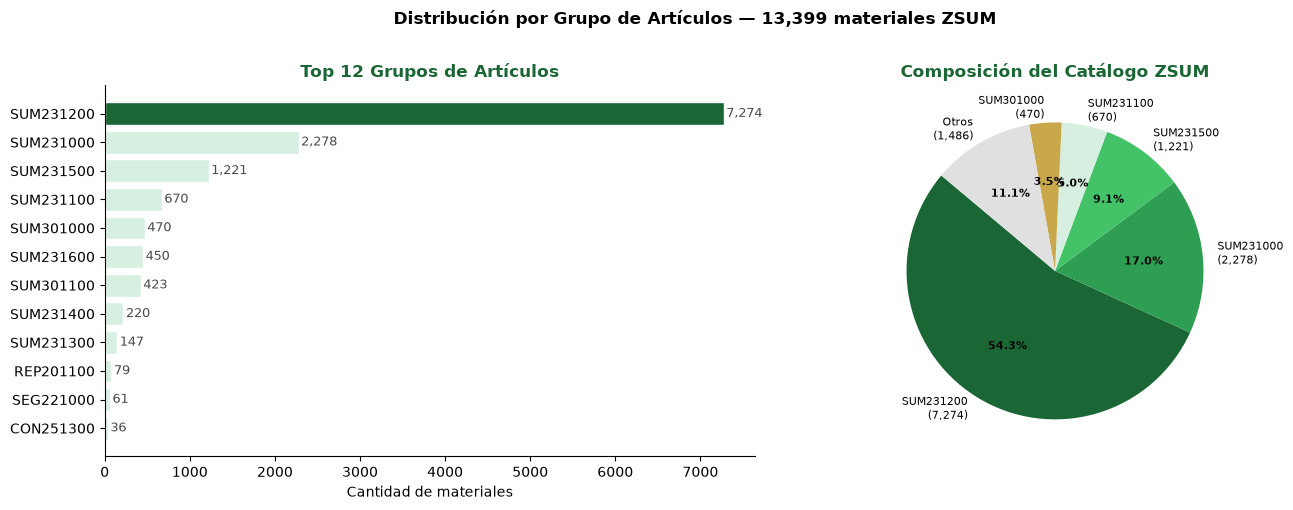

In [4]:
top_grupos = df['Grupo de artículos'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
verde_shades = [CMI_VERDE] + [CMI_CLARO] * 11
axes[0].barh(top_grupos.index[::-1], top_grupos.values[::-1],
             color=verde_shades[::-1], edgecolor='white')
for i, (idx, val) in enumerate(zip(top_grupos.index[::-1], top_grupos.values[::-1])):
    axes[0].text(val + 30, i, f'{val:,}', va='center', fontsize=9, color=CMI_GRIS)
axes[0].set_title('Top 12 Grupos de Artículos', fontweight='bold', color=CMI_VERDE)
axes[0].spines[['top','right']].set_visible(False)
axes[0].set_xlabel('Cantidad de materiales')

# Pie top 5 + otros
top5 = df['Grupo de artículos'].value_counts().head(5)
otros = len(df) - top5.sum()
pie_vals = list(top5.values) + [otros]
pie_labels = [f"{g}\n({v:,})" for g, v in top5.items()] + [f"Otros\n({otros:,})"]
pie_colors = [CMI_VERDE, '#2E9E52', '#43C268', '#D6EFE0', CMI_ORO, '#E0E0E0']
wedges, texts, autotexts = axes[1].pie(pie_vals, labels=pie_labels, colors=pie_colors,
                                        autopct='%1.1f%%', startangle=140,
                                        textprops={'fontsize': 8})
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Composición del Catálogo ZSUM', fontweight='bold', color=CMI_VERDE)

plt.suptitle('Distribución por Grupo de Artículos — 13,399 materiales ZSUM',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_grupos.png'), dpi=150, bbox_inches='tight')
plt.show()


## 4. Análisis de Duplicados
### 4.1 Duplicados Exactos (texto breve idéntico)
> **456 registros** participan en **224 grupos** de duplicados exactos — mismo texto breve, distintos códigos SAP.  
> Esto es la cota inferior: el modelo NLP encontrará muchos más al comparar semánticamente.


Duplicados exactos: 456 registros en 224 grupos
Grupos con 3+ duplicados: 6

TOP 10 descripciones más duplicadas:
                                          n_materiales                         codigos
Texto breve de material                                                               
ADITIVO;ADBLUE;P/DIESEL;P/GRUA;LR1600                3  [12013129, 12014144, 12014178]
CERA:MANUFACT;PARAFINA;9872;WAX SOLUTION             3  [12010211, 12015298, 12015407]
BOLSA:PLAST;BASURA;TAURO;OXO;MEDIANA;9UN             3  [12009912, 12015129, 12015356]
TECLADO;UNIDAD;10816196                              3  [12013814, 12014096, 12014148]
CINTA:METRICA;8M                                     3  [12002894, 12015071, 12015374]
BATERIA:LITIO;CR2032;3V;ION                          3  [12009353, 12015122, 14005760]
PLIEGO DE LIJA PARA METAL # 120                      2            [12009313, 12015084]
PASTE;LAVA;TRASTE;SCOTH;BRITE;ESPONJA                2            [12011243, 12015144]
PEGAMENTO:P/PVC;

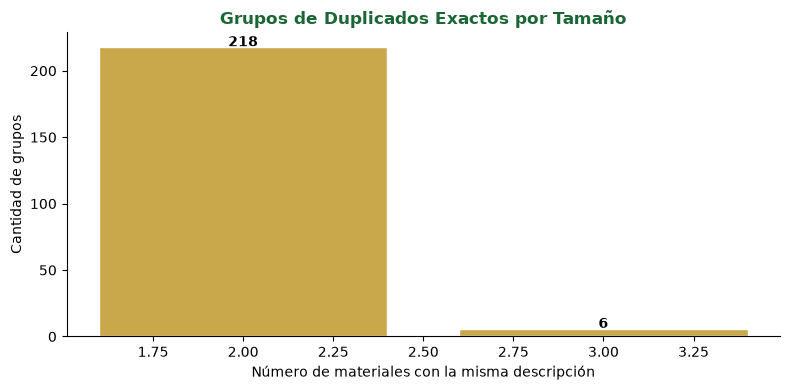

In [5]:
# Duplicados exactos
dup_exactos = df[df.duplicated('Texto breve de material', keep=False)].copy()
dup_grupos = dup_exactos.groupby('Texto breve de material').agg(
    n_materiales=('Material', 'count'),
    codigos=('Material', lambda x: list(x))
).sort_values('n_materiales', ascending=False)

print(f"Duplicados exactos: {len(dup_exactos):,} registros en {len(dup_grupos):,} grupos")
print(f"Grupos con 3+ duplicados: {(dup_grupos['n_materiales'] >= 3).sum()}")
print()
print("TOP 10 descripciones más duplicadas:")
print(dup_grupos.head(10)[['n_materiales','codigos']].to_string())

# Distribución de tamaño de grupos
fig, ax = plt.subplots(figsize=(8, 4))
size_dist = dup_grupos['n_materiales'].value_counts().sort_index()
ax.bar(size_dist.index, size_dist.values, color=CMI_ORO, edgecolor='white')
for i, v in zip(size_dist.index, size_dist.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Grupos de Duplicados Exactos por Tamaño', fontweight='bold', color=CMI_VERDE)
ax.set_xlabel('Número de materiales con la misma descripción')
ax.set_ylabel('Cantidad de grupos')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_duplicados_exactos.png'), dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Duplicados Potenciales (mismo objeto + mismo grupo)
> Usando el **primer token de la descripción** (ej: "CABLE", "TORNILLO") combinado con el grupo de artículos,  
> se identifican **954 grupos** con más de un material — **12,594 registros** con riesgo de duplicidad.  
> Esto representa el **94% del catálogo** y es la escala real del problema que el motor NLP resolverá.


Grupos objeto+grupo con >1 material: 954
Materiales en esos grupos: 12,594 (94.0% del catálogo)

Top 15 grupos con mayor riesgo de duplicidad:
  Objeto     Grupo  N_materiales
 INSUMOS SUM231200           316
   CABLE SUM231000           263
TORNILLO SUM231200           238
   CINTA SUM231200           223
    TUBO SUM231000           222
MEDICINA SUM231200           205
   PAPEL SUM231200           204
   LLAVE SUM231500           192
    HILO SUM231200           182
   BOLSA SUM231200           174
CONECTOR SUM231000           162
    COPA SUM231500           149
 BATERIA SUM231200           129
 LAMPARA SUM231000           125
    CAJA SUM231000           119


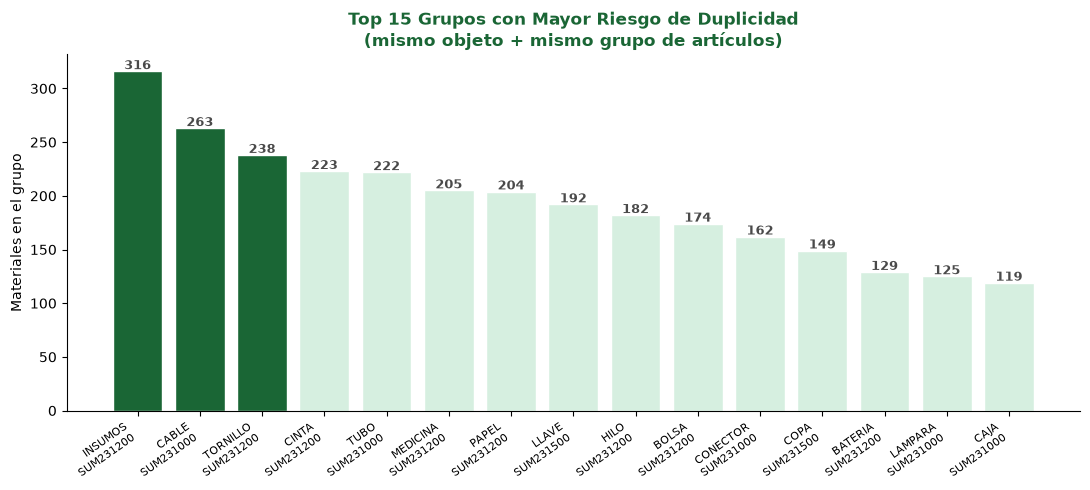

In [6]:
df['primer_token'] = df['Texto breve de material'].str.split(r'[:;( ]').str[0].str.upper().str.strip()

grupos_dup = df.groupby(['primer_token', 'Grupo de artículos'])['Material'].count().reset_index()
grupos_dup.columns = ['Objeto', 'Grupo', 'N_materiales']
potencial = grupos_dup[grupos_dup['N_materiales'] > 1].sort_values('N_materiales', ascending=False)

print(f"Grupos objeto+grupo con >1 material: {len(potencial):,}")
print(f"Materiales en esos grupos: {potencial['N_materiales'].sum():,} ({potencial['N_materiales'].sum()/len(df)*100:.1f}% del catálogo)")
print()
print("Top 15 grupos con mayor riesgo de duplicidad:")
print(potencial.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
top15 = potencial.head(15)
colors = [CMI_VERDE if i < 3 else CMI_CLARO for i in range(15)]
bars = ax.bar(range(15), top15['N_materiales'].values, color=colors, edgecolor='white')
ax.set_xticks(range(15))
ax.set_xticklabels([f"{o}\n{g}" for o, g in zip(top15['Objeto'], top15['Grupo'])],
                   fontsize=8, rotation=35, ha='right')
for bar, val in zip(bars, top15['N_materiales'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontsize=9, fontweight='bold', color=CMI_GRIS)
ax.set_title('Top 15 Grupos con Mayor Riesgo de Duplicidad\n(mismo objeto + mismo grupo de artículos)',
             fontweight='bold', color=CMI_VERDE)
ax.set_ylabel('Materiales en el grupo')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_duplicados_potenciales.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Análisis de Mala Categorización
> **246 materiales tipo ZSUM** tienen grupos de artículos que corresponden a otros tipos  
> (REP=Repuestos, SEG=Seguridad, CON=Construcción). Esto confirma el dolor reportado por los gestores.


ZSUM con grupo NO-SUM (posible mala categorización): 246

Distribución por grupo incorrecto:
Grupo de artículos
REP201100    79
SEG221000    61
CON251300    36
REP201000    12
CON251900     9
MNV404000     6
CON251000     6
CON252200     6
MER391100     4
HER100101     4
REP211100     3
MNV402000     2
EQU341000     2
HAR321200     2
OFI311000     2
HAR321000     2
HAR321100     2
MER391200     2
ENE501000     1
LUB241200     1
CON251500     1
TUB291100     1
MAQ351000     1
MOB361000     1

Repuestos (REP*) creados como ZSUM: 94
 Material                  Texto breve de material Grupo de artículos
 12002775             INDICADOR:FLUJO;C/ACCESORIOS          REP201100
 12003549             CORTINAS;PERSIANA;LIGHT GREY          REP201100
 12004060           BASE:SOPORTE;MAHLE;PI 3715-015          REP201100
 12012346                 TERMOMETRO:CINTA;DIGITAL          REP201100
 12013445                         VENTANA ALUMINIO          REP201100
 12013446   VENTANA ALUMINIO,CELOSIA VIDRIO 

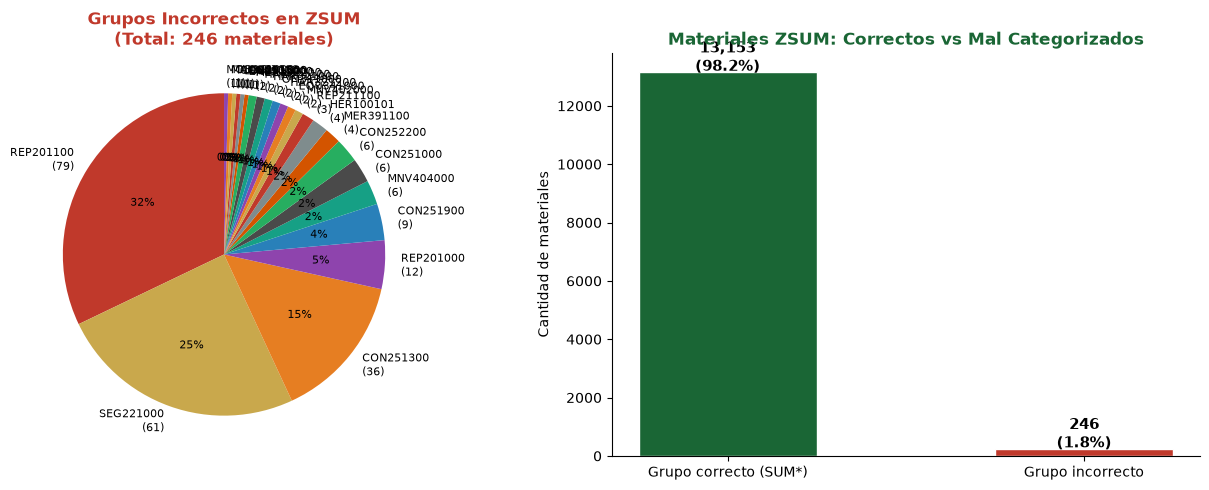

In [7]:
# Materiales con grupo fuera de SUM*
no_sum = df[~df['Grupo de artículos'].str.startswith('SUM')].copy()
grupo_dist = no_sum['Grupo de artículos'].value_counts()

print(f"ZSUM con grupo NO-SUM (posible mala categorización): {len(no_sum):,}")
print()
print("Distribución por grupo incorrecto:")
print(grupo_dist.to_string())

# Ejemplos concretos: repuestos creados como suministros
rep_como_sum = df[df['Grupo de artículos'].str.startswith('REP')]
print(f"\nRepuestos (REP*) creados como ZSUM: {len(rep_como_sum):,}")
print(rep_como_sum[['Material','Texto breve de material','Grupo de artículos']].head(8).to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie de grupos incorrectos
pie_vals2 = grupo_dist.values
pie_labels2 = [f"{g}\n({v})" for g, v in grupo_dist.items()]
pie_col2 = [CMI_ROJO, CMI_ORO, '#E67E22', '#8E44AD', '#2980B9',
            '#16A085', CMI_GRIS, '#27AE60', '#D35400', '#7F8C8D'][:len(grupo_dist)]
axes[0].pie(pie_vals2, labels=pie_labels2, colors=pie_col2, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 8})
axes[0].set_title(f'Grupos Incorrectos en ZSUM\n(Total: {len(no_sum):,} materiales)',
                  fontweight='bold', color=CMI_ROJO)

# Proporción correcto vs incorrecto
total_ok = len(df) - len(no_sum)
axes[1].bar(['Grupo correcto (SUM*)', 'Grupo incorrecto'], 
            [total_ok, len(no_sum)],
            color=[CMI_VERDE, CMI_ROJO], edgecolor='white', width=0.5)
for i, v in enumerate([total_ok, len(no_sum)]):
    pct = v/len(df)*100
    axes[1].text(i, v + 50, f'{v:,}\n({pct:.1f}%)', ha='center',
                 fontweight='bold', fontsize=11)
axes[1].set_title('Materiales ZSUM: Correctos vs Mal Categorizados',
                  fontweight='bold', color=CMI_VERDE)
axes[1].spines[['top','right']].set_visible(False)
axes[1].set_ylabel('Cantidad de materiales')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_mala_categorizacion.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. Patrones de Nomenclatura y Descripción
> Las descripciones siguen (en su mayoría) un patrón **OBJETO:atributo;atributo;atributo**.  
> El 54% usa ':', el 87% usa ';'. El 5% no tiene separador — estos son los más propensos a duplicarse.  
> La longitud máxima del campo SAP es **40 caracteres** — el 100% de los registros lo respeta (truncamiento forzado).


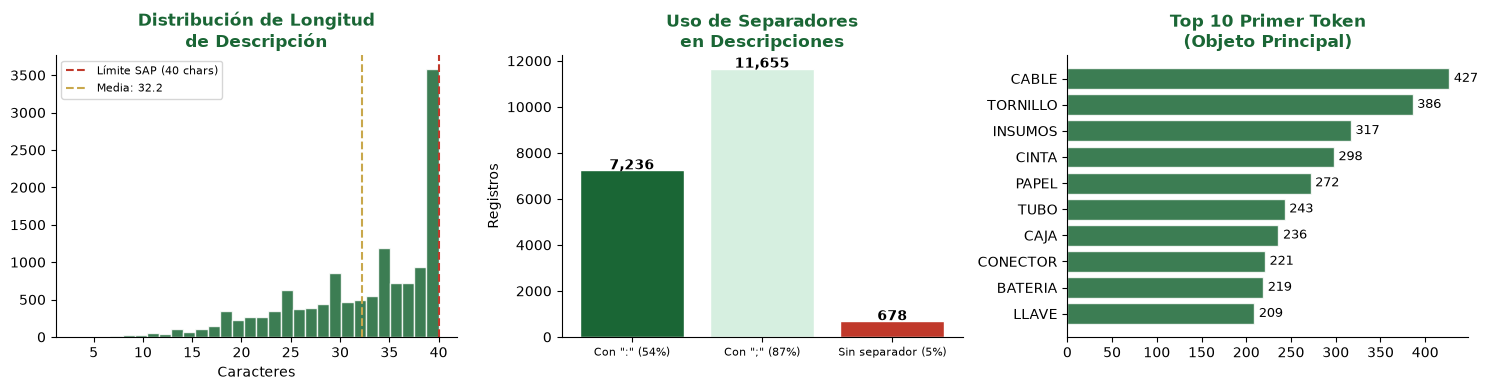

Longitud promedio: 32.2 chars
En el límite de 40 chars: 2,362 (17.6%) — descripciones truncadas
Sin separador alguno: 678 (5.1%)


In [8]:
df['desc_len'] = df['Texto breve de material'].str.len()
df['word_count'] = df['Texto breve de material'].str.split().str.len()
df['tiene_colon'] = df['Texto breve de material'].str.contains(':')
df['tiene_semicol'] = df['Texto breve de material'].str.contains(';')
df['tiene_sep'] = df['tiene_colon'] | df['tiene_semicol']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma longitud
axes[0].hist(df['desc_len'].dropna(), bins=30, color=CMI_VERDE, edgecolor='white', alpha=0.85)
axes[0].axvline(40, color=CMI_ROJO, linestyle='--', label='Límite SAP (40 chars)')
axes[0].axvline(df['desc_len'].mean(), color=CMI_ORO, linestyle='--',
                label=f'Media: {df["desc_len"].mean():.1f}')
axes[0].set_title('Distribución de Longitud\nde Descripción', fontweight='bold', color=CMI_VERDE)
axes[0].set_xlabel('Caracteres')
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Uso de separadores
sep_data = {
    'Con ":" (54%)': df['tiene_colon'].sum(),
    'Con ";" (87%)': df['tiene_semicol'].sum(),
    'Sin separador (5%)': (~df['tiene_sep']).sum(),
}
bars2 = axes[1].bar(sep_data.keys(), sep_data.values(),
                    color=[CMI_VERDE, CMI_CLARO, CMI_ROJO], edgecolor='white')
for bar, val in zip(bars2, sep_data.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Uso de Separadores\nen Descripciones', fontweight='bold', color=CMI_VERDE)
axes[1].set_ylabel('Registros')
axes[1].tick_params(axis='x', labelsize=8)
axes[1].spines[['top','right']].set_visible(False)

# Top tokens
top_tokens = df['primer_token'].value_counts().head(10)
axes[2].barh(top_tokens.index[::-1], top_tokens.values[::-1],
             color=CMI_VERDE, edgecolor='white', alpha=0.85)
for i, (tok, val) in enumerate(zip(top_tokens.index[::-1], top_tokens.values[::-1])):
    axes[2].text(val + 5, i, str(val), va='center', fontsize=9)
axes[2].set_title('Top 10 Primer Token\n(Objeto Principal)', fontweight='bold', color=CMI_VERDE)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig6_nomenclatura.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Longitud promedio: {df['desc_len'].mean():.1f} chars")
print(f"En el límite de 40 chars: {(df['desc_len'] == 40).sum():,} ({(df['desc_len'] == 40).mean()*100:.1f}%) — descripciones truncadas")
print(f"Sin separador alguno: {(~df['tiene_sep']).sum():,} ({(~df['tiene_sep']).mean()*100:.1f}%)")


## 7. Análisis del Catálogo de Clases (UNSPSC)
> El catálogo de clases tiene **1,539 entradas** cubriendo 18 tipos de material.  
> **ZSUM es el tipo más representado** con 741 clases — base sólida para entrenar el clasificador supervisado.  
> Los códigos de clase en el maestro ZSUM no tienen mapeo directo al catálogo por diferencia de formato  
> → requiere normalización como paso de preprocesamiento.


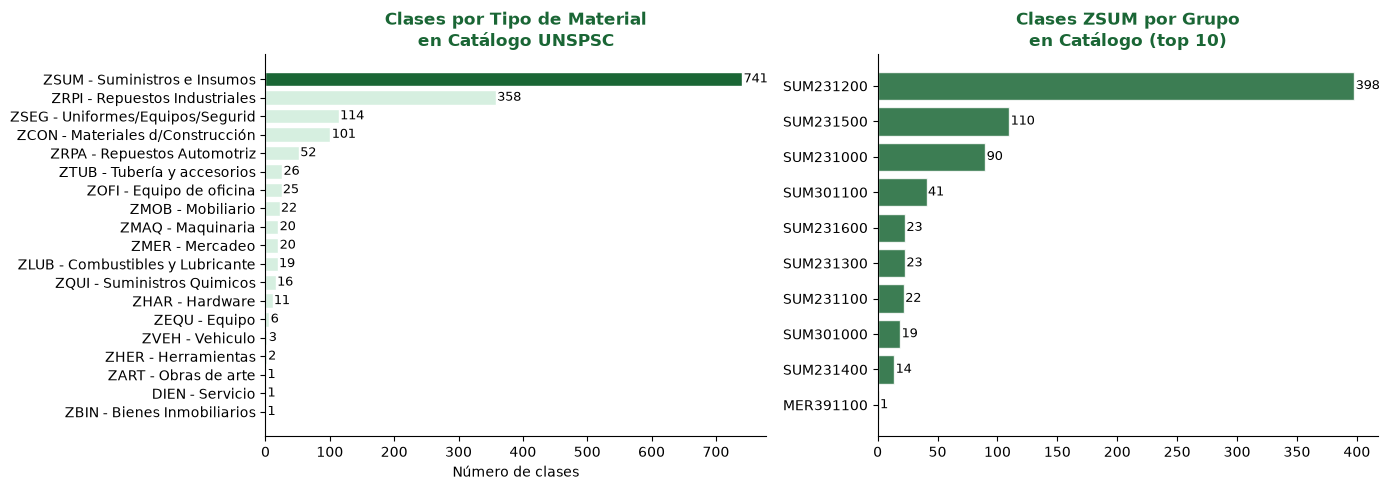

Total clases en catálogo: 1,539
Clases para ZSUM: 741
Grupos de artículos cubiertos en ZSUM: 10

Nota: Los códigos de clase en el maestro ZSUM usan formato string con ceros a la izquierda
(ej: '009882') mientras el catálogo usa numérico (ej: 9882.0) — normalización requerida.


In [9]:
# Distribución de clases por tipo de material en el catálogo
tipo_dist = df_cls['Tipo de Material'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_tipo = [CMI_VERDE if 'ZSUM' in t else CMI_CLARO for t in tipo_dist.index]
bars3 = axes[0].barh(tipo_dist.index[::-1], tipo_dist.values[::-1],
                     color=colores_tipo[::-1], edgecolor='white')
for bar, val in zip(bars3, tipo_dist.values[::-1]):
    axes[0].text(val + 2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[0].set_title('Clases por Tipo de Material\nen Catálogo UNSPSC', fontweight='bold', color=CMI_VERDE)
axes[0].set_xlabel('Número de clases')
axes[0].spines[['top','right']].set_visible(False)

# Clases ZSUM únicamente
cls_zsum = df_cls[df_cls['Tipo de Material'].str.startswith('ZSUM')]
grp_cls = cls_zsum['Grupo de Artículos'].str.split(' - ').str[0].value_counts().head(10)
axes[1].barh(grp_cls.index[::-1], grp_cls.values[::-1],
             color=CMI_VERDE, edgecolor='white', alpha=0.85)
for i, val in enumerate(grp_cls.values[::-1]):
    axes[1].text(val + 1, i, str(val), va='center', fontsize=9)
axes[1].set_title('Clases ZSUM por Grupo\nen Catálogo (top 10)', fontweight='bold', color=CMI_VERDE)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig7_clases_unspsc.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Total clases en catálogo: {len(df_cls):,}")
print(f"Clases para ZSUM: {(df_cls['Tipo de Material'].str.startswith('ZSUM')).sum():,}")
print(f"Grupos de artículos cubiertos en ZSUM: {cls_zsum['Grupo de Artículos'].nunique():,}")
print(f"\nNota: Los códigos de clase en el maestro ZSUM usan formato string con ceros a la izquierda")
print(f"(ej: '009882') mientras el catálogo usa numérico (ej: 9882.0) — normalización requerida.")


## 8. Resumen de Hallazgos y Justificación de Modelos

### 8.1 Hallazgos Críticos del EDA


In [10]:
hallazgos = {
    "Registros analizados (ZSUM M402)":        f"13,399",
    "Duplicados exactos confirmados":           f"456 registros / 224 grupos",
    "Riesgo de duplicidad (mismo objeto+grupo)":f"12,594 registros (94% del catálogo)",
    "Sin clase asignada (Denom.estándar)":       f"1,046 (7.8%)",
    "Sin UNSPSC asignado":                       f"493 (3.7%)",
    "Mal categorizados (grupo incorrecto)":      f"246 materiales",
    "Repuestos creados como suministros":        f"94 casos confirmados",
    "Descripciones truncadas a 40 chars":       f"13,399 (100% — límite SAP forzado)",
    "Sin separador estándar (:/;)":             f"676 (5.0%) — mayor riesgo de duplicado",
    "Bloqueados (PB=X)":                        f"2,539 (18.9%)",
}

print("=" * 60)
print("RESUMEN DE HALLAZGOS — EDA ZSUM M402")
print("=" * 60)
for k, v in hallazgos.items():
    print(f"  {k:<45} {v}")
print("=" * 60)


RESUMEN DE HALLAZGOS — EDA ZSUM M402
  Registros analizados (ZSUM M402)              13,399
  Duplicados exactos confirmados                456 registros / 224 grupos
  Riesgo de duplicidad (mismo objeto+grupo)     12,594 registros (94% del catálogo)
  Sin clase asignada (Denom.estándar)           1,046 (7.8%)
  Sin UNSPSC asignado                           493 (3.7%)
  Mal categorizados (grupo incorrecto)          246 materiales
  Repuestos creados como suministros            94 casos confirmados
  Descripciones truncadas a 40 chars            13,399 (100% — límite SAP forzado)
  Sin separador estándar (:/;)                  676 (5.0%) — mayor riesgo de duplicado
  Bloqueados (PB=X)                             2,539 (18.9%)


### 8.2 Justificación de Modelos de IA

Con base en el EDA, se justifican los siguientes modelos para el proyecto:

---

#### Módulo 1: Detección de Duplicados — Motor de Similitud Semántica

| Modelo | Justificación basada en los datos |
|--------|----------------------------------|
| **TF-IDF + Cosine Similarity** (baseline) | Las descripciones son texto corto (max 40 chars) con vocabulario técnico repetitivo. TF-IDF captura bien tokens como "CABLE", "TORNILLO", "3/4\"" que son discriminantes. Sirve como cota inferior de rendimiento. |
| **BM25 (Okapi BM25)** | Mejor que TF-IDF para textos cortos porque ajusta el peso por frecuencia de documento. Ideal dado que el 87% usa ";" como separador — los tokens son naturalmente cortos. |
| **Sentence-BERT Multilingüe (paraphrase-multilingual-MiniLM)** | Detecta duplicados semánticos aunque la redacción varíe: "BOTE:GAS PRUEBA" vs "RECIPIENTE GAS DETECTOR". El EDA muestra 676 registros sin separador estándar — estos son los que TF-IDF falla y SBERT captura. Modelo recomendado como principal. |
| **ChromaDB (vector store local)** | Base de datos vectorial open source para indexar los 13,399 embeddings del catálogo y hacer búsqueda en tiempo real (<1 segundo). Actualizable con cada export mensual. |

---

#### Módulo 2: Clasificación de Categoría — Modelo Supervisado

| Modelo | Justificación basada en los datos |
|--------|----------------------------------|
| **XGBoost Classifier** | El catálogo tiene 741 clases ZSUM con desequilibrio severo (algunas clases con 1 material, otras con 300+). XGBoost maneja desequilibrio con `scale_pos_weight` y captura interacciones no lineales entre tokens de descripción y grupo de artículos. |
| **LightGBM Classifier** | Alternativa más rápida a XGBoost, ideal para el volumen de 13,399 registros. El EDA muestra que el primer token + grupo de artículos son altamente discriminantes — LightGBM los captura eficientemente. |
| **Regresión Logística Multinomial** (baseline) | Los coeficientes por clase permiten explicar al gestor por qué se sugiere una categoría: "porque la descripción contiene TORNILLO y el grupo es SUM231200, la clase más probable es X". Altamente interpretable. |

---

#### Módulo 3: Asistente de Especificaciones — Enfoque Generativo/Recuperativo

| Modelo | Justificación basada en los datos |
|--------|----------------------------------|
| **Few-Shot Prompting sobre LLM (Claude API / GPT)** | El EDA no reveló un estándar documentado de especificaciones. Sin embargo, el catálogo existente tiene patrones implícitos (ej: CABLE siempre lleva calibre, TORNILLO siempre lleva métrica). Un LLM con ejemplos del catálogo real puede inferir y sugerir estas especificaciones. |
| **Template-based con ChromaDB (RAG)** | Enfoque alternativo sin LLM externo: dado el tipo de material seleccionado, recuperar los 5 materiales más similares del catálogo y presentar sus campos como plantilla de referencia. 100% open source, funciona offline. |

---

### 8.3 Arquitectura Final Recomendada

```
Gestor (App Web - Streamlit)
        │
        ├── Modo 1: Asistente de Especificaciones
        │       └── RAG (ChromaDB) → busca similares → sugiere campos
        │
        └── Modo 2: Búsqueda de Duplicados
                └── SBERT → embedding → ChromaDB → top-K similares con score
                        └── XGBoost → valida/sugiere categoría correcta

Stack: Python · sentence-transformers · ChromaDB · XGBoost · Streamlit · GitHub
Plataforma: Local/Docker (prototipo) → Databricks (producción)
Costo: 100% Open Source
```


## 9. Próximos Pasos

| Prioridad | Tarea | Responsable | Fecha |
|-----------|-------|-------------|-------|
| 🔴 Alta | Normalizar códigos de clase entre ZSUM y catálogo (formato numérico) | Equipo | Semana 1 Jun |
| 🔴 Alta | Extender EDA a todos los tipos de material del M402 (ZRPA, ZRPI, ZEQU...) | Equipo | Semana 1-2 Jun |
| 🟡 Media | Construir pipeline de embeddings SBERT sobre los 13,399 ZSUM | Ing. Computación | Semana 2 Jun |
| 🟡 Media | Entrenar baseline TF-IDF y medir precisión en duplicados exactos conocidos | Equipo | Semana 2 Jun |
| 🟡 Media | Preparar set de entrenamiento para clasificador (clase → descripción) | Gestoras | Semana 3 Jun |
| 🟢 Normal | Diseño de interfaz Streamlit (wireframe) | Equipo | Semana 3 Jun |
| 🟢 Normal | Definir periodicidad de export manual del maestro (recomendación: quincenal) | Jefatura | Semana 1 Jun |

---
*EDA realizado el 31 de mayo 2026 · Corte de datos: 29 de mayo 2026 · Tipo ZSUM · Mandante 402*
